In [86]:
import mytorch
import mytorch.layer
import mytorch.activation
import mytorch.optimizer
import mytorch.loss
import pandas as pd
import matplotlib.pyplot as plt
from mytorch.tensor import Tensor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
FILE_PATH = r".\diabetes.csv"

In [87]:
# #don't change this cell
df = pd.read_csv(FILE_PATH, header=0)

# Rename Outcome to Diagnosis and convert to binary (already 0/1)
df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [88]:
columns_to_fix_med = ['Glucose', 'BloodPressure']
columns_to_fix_mea = ['BMI','SkinThickness','Insulin']

for col in columns_to_fix_mea:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    mean_value = df[col].mean()
    df[col] = df[col].replace(np.nan, mean_value)
    
for col in columns_to_fix_med:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    median_value = df[col].median()
    df[col] = df[col].replace(np.nan, median_value)

In [89]:
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values
y = y.reshape(-1, 1) 

scaler= StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = mytorch.Tensor(X_train)
y_train = mytorch.Tensor(y_train)   

X_test_org = mytorch.Tensor(X_test)
y_test_org = mytorch.Tensor(y_test)

X_test = mytorch.Tensor(X_val)
y_test = mytorch.Tensor(y_val)



In [90]:
class msig(mytorch.Model):
    def __init__(self, input_size):
        super(msig, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.sigmoid = mytorch.activation.sigmoid
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.sigmoid(self.l4(x))
        return x
    
class mrelu(mytorch.Model):
    def __init__(self, input_size):
        super(mrelu, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.relu(self.l4(x))
        return x
    
class mleaky(mytorch.Model):
    def __init__(self, input_size):
        super(mleaky, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.leaky_relu = mytorch.activation.leaky_relu
            
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.leaky_relu(self.l4(x))
        return x
    
    
class msoft(mytorch.Model):
    def __init__(self, input_size):
        super(msoft, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.softmax = mytorch.activation.softmax
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.softmax(self.l4(x))
        return x
    
class mstep(mytorch.Model):
    def __init__(self, input_size):
        super(mstep, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.step= mytorch.activation.step
        
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.step(self.l4(x))
        return x
    
class mtanh(mytorch.Model):
    def __init__(self, input_size):
        super(mtanh, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        self.relu = mytorch.activation.relu
        self.tanh = mytorch.activation.tanh
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.tanh(self.l4(x))
        return x



In [91]:
y_train_binary = mytorch.Tensor(y_train.data.astype(float))
y_test_binary = mytorch.Tensor(y_test.data.astype(float))
input_size = X.shape[1]
NUM_EPOCHS = 100
# criterion = mytorch.loss.ce.BinaryCrossEntropy

model_sig = msig(input_size)
model_relu = mrelu(input_size)
model_leaky = mleaky(input_size)
model_soft = msoft(input_size)
model_step = mstep(input_size)
model_tanh = mtanh(input_size)


In [92]:
metrics_df = pd.DataFrame(columns=["Epoch", "Model", "Train_Loss", "Train_Accuracy", "Test_Loss", "Test_Accuracy"])
names = ['Sigmoid', 'ReLU', 'Leaky ReLU', 'Softmax', 'Step', 'Tanh']
models = [ model_sig , model_relu, model_leaky, model_soft, model_step, model_tanh ]


In [95]:

batch_size = 64
for mdl,name in zip(models, names):
    optimizer = mytorch.optimizer.Adam(mdl.layers, lr=0.0001)

    train_accuracy_list = []
    test_accuracy_list = []
    for epoch in range(NUM_EPOCHS):
        total = 0
        corrects = 0
        running_loss = 0.0

        for i in range(0, X_train.shape[0], batch_size):
            inputs = X_train[i:i+batch_size]
            labels = y_train[i:i+batch_size]
            
            optimizer.zero_grad()
            outputs = mdl.forward(inputs)
            
            loss = mytorch.loss.ce.BinaryCrossEntropy(outputs, labels) 
            loss = loss.sum()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.data.sum()
            total += labels.data.shape[0]
            
            pred = (outputs.data > 0.5).astype(float)
            corrects += (pred == labels.data).astype(int).sum().item()
            
            
        epoch_loss = running_loss / total
        train_accuracy = corrects / total
        train_accuracy_list.append(train_accuracy)
        
        print(f"{name} :Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {train_accuracy:.4f}")
        
        
        outputs_test = mdl.forward(X_test)
        pred_test = (outputs_test.data > 0.5).astype(float)
        correct = (pred_test == y_test_binary.data).astype(int).sum().item()
        
        test_loss = mytorch.loss.ce.BinaryCrossEntropy(outputs_test, y_test_binary).data.sum() / y_test_binary.data.shape[0]
        total = y_test_binary.data.shape[0]
        test_accuracy = correct / total
        test_accuracy_list.append(test_accuracy)
        
        print(f"Test Accuracy {name}: {test_accuracy:.4f}", end="\n\n")

    
        metrics_df = pd.concat([metrics_df, pd.DataFrame.from_dict([{
                "Epoch": epoch+1,
                "Model": name,
                "Train_Loss": epoch_loss,
                "Train_Accuracy": train_accuracy,
                "Test_Loss": test_loss,
                "Test_Accuracy": test_accuracy
            }])], ignore_index=True)
    

Sigmoid :Epoch 1/100, Loss: 0.4335, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 2/100, Loss: 0.4333, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 3/100, Loss: 0.4332, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 4/100, Loss: 0.4330, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 5/100, Loss: 0.4329, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 6/100, Loss: 0.4327, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 7/100, Loss: 0.4325, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 8/100, Loss: 0.4322, Accuracy: 0.7848
Test Accuracy Sigmoid: 0.7662

Sigmoid :Epoch 9/100, Loss: 0.4320, Accuracy: 0.7826
Test Accuracy Sigmoid: 0.7597

Sigmoid :Epoch 10/100, Loss: 0.4318, Accuracy: 0.7804
Test Accuracy Sigmoid: 0.7532

Sigmoid :Epoch 11/100, Loss: 0.4315, Accuracy: 0.7804
Test Accuracy Sigmoid: 0.7532

Sigmoid :Epoch 12/100, Loss: 0.4312, Accuracy: 0.7783
Test Accuracy Sigmoi

d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:190: RuntimeWarning: invalid value encountered in log
  data = np.log(t.data)


Leaky ReLU :Epoch 14/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 15/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 16/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 17/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 18/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 19/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 20/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 21/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 22/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 23/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 24/100, Loss: nan, Accuracy: 0.6391
Test Accuracy Leaky ReLU: 0.6753

Leaky ReLU :Epoch 25/100, Loss: 

d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:190: RuntimeWarning: divide by zero encountered in log
  data = np.log(t.data)
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:329: RuntimeWarning: invalid value encountered in multiply
  data = t1.data * t2.data
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:199: RuntimeWarning: divide by zero encountered in divide
  return grad / t.data
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\tensor.py:199: RuntimeWarning: invalid value encountered in divide
  return grad / t.data
d:\sem5\ci\CI_Project1_Fall1404\first_project 2\mytorch\activation\step.py:12: RuntimeWarning: invalid value encountered in multiply
  return grad * 0


Step :Epoch 35/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 36/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 37/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 38/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 39/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 40/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 41/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 42/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 43/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 44/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 45/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 46/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 47/100, Loss: nan, Accuracy: 0.3609
Test Accuracy Step: 0.3247

Step :Epoch 

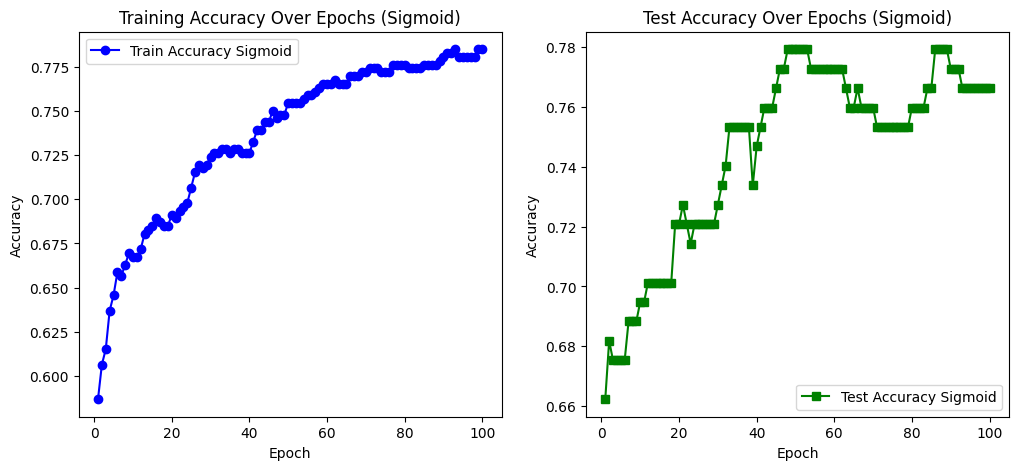

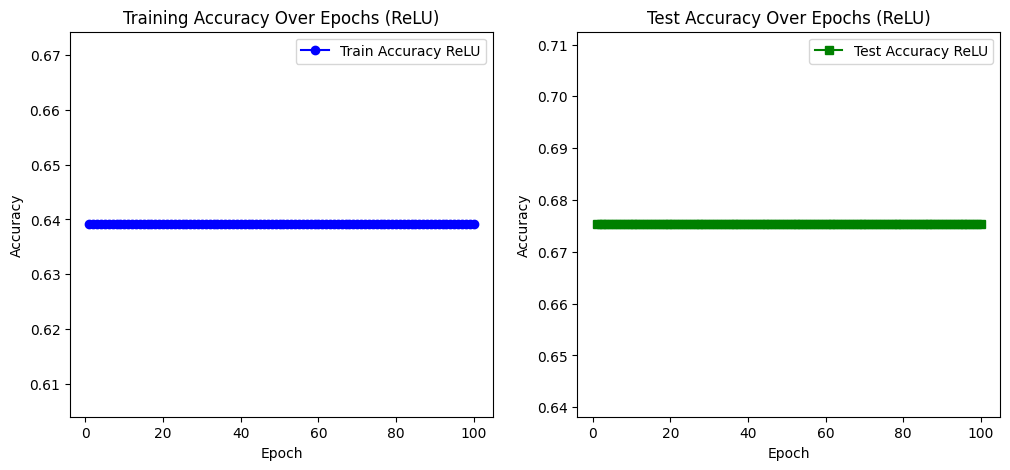

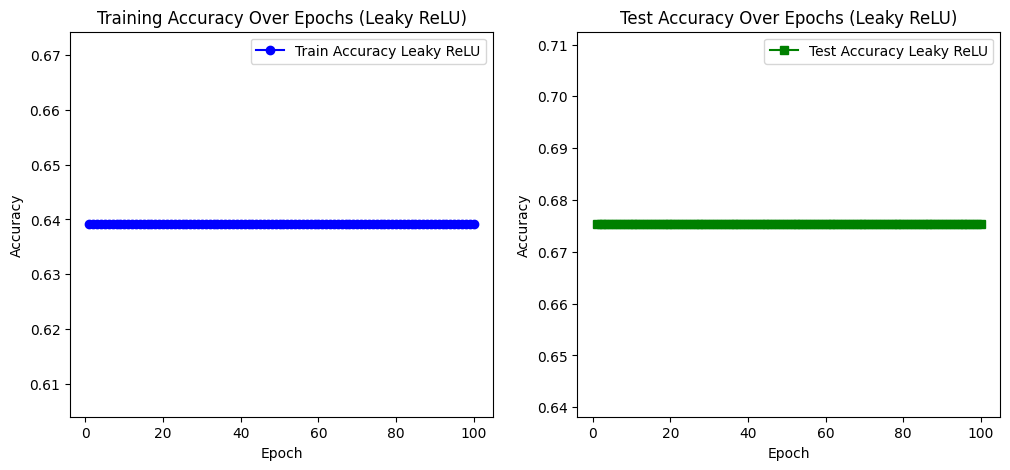

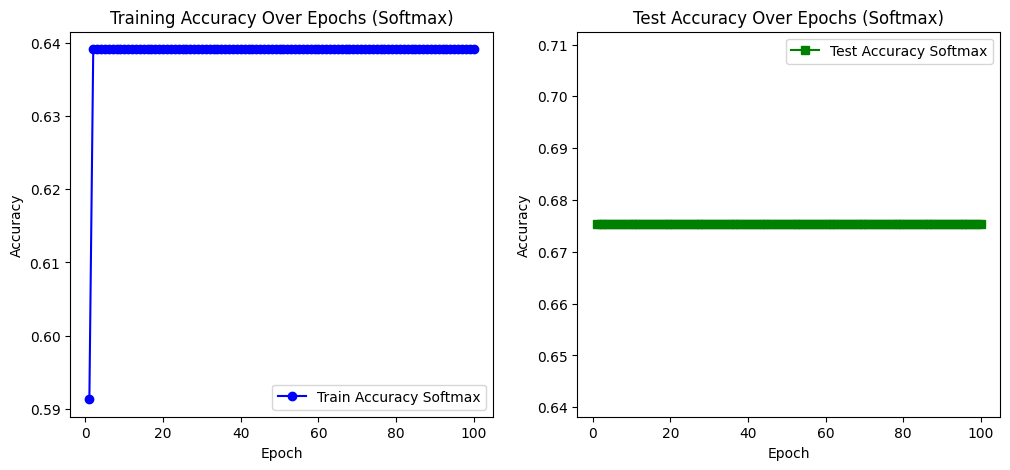

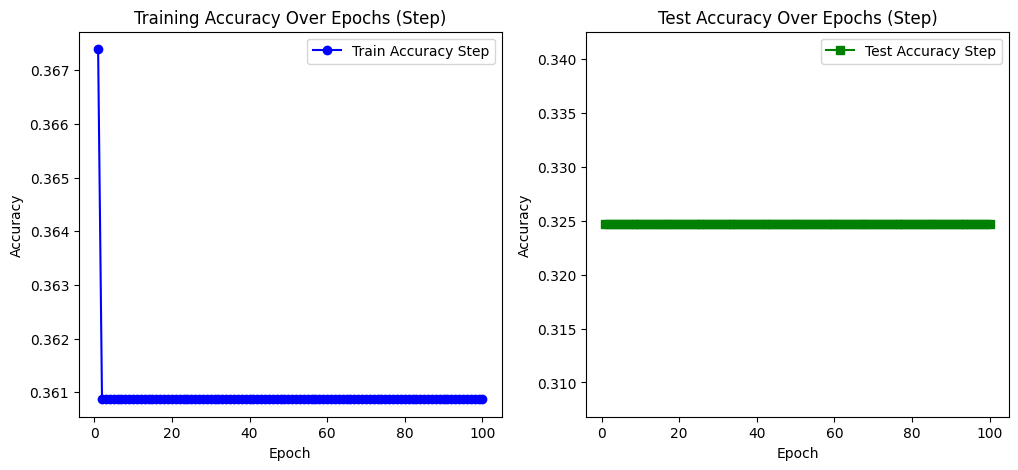

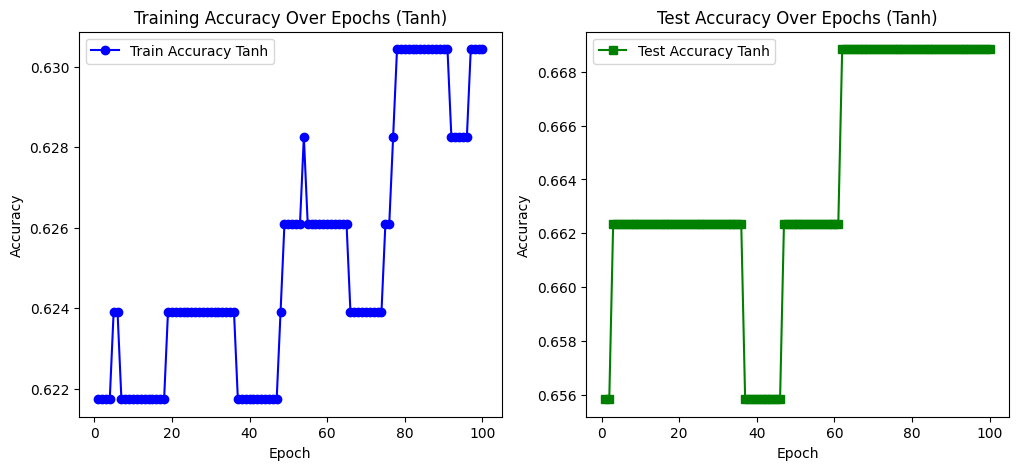

In [94]:
# don't change this cell
for model_name in metrics_df["Model"].unique():
    df_model = metrics_df[metrics_df["Model"] == model_name]
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df_model["Epoch"], df_model["Train_Accuracy"], marker='o', linestyle='-', color='b',
             label=f"Train Accuracy {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training Accuracy Over Epochs ({model_name})")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df_model["Epoch"], df_model["Test_Accuracy"], marker='s', linestyle='-', color='g',
             label=f"Test Accuracy {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Test Accuracy Over Epochs ({model_name})")
    plt.legend()

    plt.show()